In [1]:
# ==========================================================
# 🟢 STEP 0B : Test Notebook (RUN ONLY ONCE)
# ==========================================================

print("Notebook is working successfully!")

Notebook is working successfully!


In [2]:
# ==========================================================
# 🟢 STEP 1 : Verify Environment & Dataset (RUN ONLY ONCE)
# ==========================================================

import os
import sys
import platform
from pathlib import Path

print("=" * 60)
print("🚀 Traffic Sign Detection using YOLOv8")
print("=" * 60)

# ---------------- Python ----------------
print("\n📌 Python")
print("Version :", platform.python_version())
print("Executable :", sys.executable)

# ---------------- Ultralytics ----------------
try:
    import ultralytics
    print("\n✅ Ultralytics Version :", ultralytics.__version__)
except:
    print("\n❌ Ultralytics is NOT installed")

# ---------------- OpenCV ----------------
try:
    import cv2
    print("✅ OpenCV Version :", cv2.__version__)
except:
    print("❌ OpenCV is NOT installed")

# ---------------- Dataset ----------------
dataset_path = Path("Self-Driving Cars.yolov8")

print("\n📌 Dataset Path")
print(dataset_path.resolve())

if dataset_path.exists():
    print("✅ Dataset Found")
else:
    print("❌ Dataset NOT Found")

# ---------------- Folder Structure ----------------

required_folders = [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels",
    "test/images",
    "test/labels"
]

print("\n📂 Folder Verification")

for folder in required_folders:

    folder_path = dataset_path / folder

    if folder_path.exists():
        print(f"✅ {folder}")
    else:
        print(f"❌ {folder}")

# ---------------- data.yaml ----------------

yaml_file = dataset_path / "data.yaml"

print("\n📄 YAML File")

if yaml_file.exists():
    print("✅ data.yaml Found")
else:
    print("❌ data.yaml Missing")

print("\n" + "=" * 60)
print("✅ STEP 1 COMPLETED")
print("=" * 60)

🚀 Traffic Sign Detection using YOLOv8

📌 Python
Version : 3.12.10
Executable : c:\Program Files\Python312\python.exe

❌ Ultralytics is NOT installed
✅ OpenCV Version : 4.13.0

📌 Dataset Path
D:\Major Project\Self-Driving Cars.yolov8
✅ Dataset Found

📂 Folder Verification
✅ train/images
✅ train/labels
✅ valid/images
✅ valid/labels
✅ test/images
✅ test/labels

📄 YAML File
✅ data.yaml Found

✅ STEP 1 COMPLETED


In [4]:
%pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.3 MB 1.0 MB/s eta 0:00:01
   ---------------------------------------  1.3/1.3 MB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 1.8 MB/s  0:00:00
   ---------------------------------------- 0.0/836.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/836.9 kB ? eta -:--:--
   ------------------------- -------------- 524.3/836.9 kB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 836.9/836.9 kB 1.7 MB/s  0:00:00
   ---------------------------------------- 0.0/52.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/52.7 MB 3.4 MB/s eta 0:00:16
    --------------------------------------- 

In [5]:
# ==========================================================
# 🟢 STEP 2A : Verify Ultralytics Installation (RUN ONLY ONCE)
# ==========================================================

import ultralytics

print("✅ Ultralytics Version :", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\ASUS\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics Version : 8.4.80


In [6]:
# ==========================================================
# 🟢 STEP 3 : Verify GPU & CUDA (RUN ONLY ONCE)
# ==========================================================

import torch

print("=" * 60)
print("🚀 PyTorch & GPU Information")
print("=" * 60)

print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name        : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version    : {torch.version.cuda}")

    total_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU Memory      : {total_memory:.2f} GB")
else:
    print("❌ GPU is NOT available.")
    print("YOLO will train on CPU, which will be much slower.")

print("=" * 60)

🚀 PyTorch & GPU Information
PyTorch Version : 2.12.1+cpu
CUDA Available  : False
❌ GPU is NOT available.
YOLO will train on CPU, which will be much slower.


In [7]:
# ==========================================================
# 🟢 STEP 4C : Verify GPU (RUN ONLY ONCE)
# ==========================================================

import torch

print("=" * 60)
print("🚀 GPU Verification")
print("=" * 60)

print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name        : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version    : {torch.version.cuda}")

    total_memory = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"GPU Memory      : {total_memory:.2f} GB")

print("=" * 60)

🚀 GPU Verification
PyTorch Version : 2.12.1+cpu
CUDA Available  : False


In [8]:
import sys
import torch

print("Python Executable:")
print(sys.executable)

print("\nTorch Location:")
print(torch.__file__)

print("\nTorch Version:")
print(torch.__version__)

Python Executable:
c:\Program Files\Python312\python.exe

Torch Location:
C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\torch\__init__.py

Torch Version:
2.12.1+cpu


In [1]:
import torch

print("Torch :", torch.__version__)
print("CUDA  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))

Torch : 2.12.1+cu126
CUDA  : True
GPU   : NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
# ==========================================================
# 🟢 PART B - STEP 1 : Import Required Libraries (RUN ONLY ONCE)
# ==========================================================

import os
import yaml
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

import numpy as np
import pandas as pd

from ultralytics import YOLO

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [3]:
# ==========================================================
# 🟢 PART B - STEP 2 : Load Dataset Information (RUN ONLY ONCE)
# ==========================================================

# Dataset Path
DATASET_PATH = Path("Self-Driving Cars.yolov8")

YAML_PATH = DATASET_PATH / "data.yaml"

# Read YAML file
with open(YAML_PATH, "r") as file:
    data = yaml.safe_load(file)

print("=" * 60)
print("📂 DATASET INFORMATION")
print("=" * 60)

print(f"Dataset Path : {DATASET_PATH.resolve()}")
print(f"Training Images Folder : {data['train']}")
print(f"Validation Images Folder : {data['val']}")
print(f"Test Images Folder : {data['test']}")

print("\nNumber of Classes :", len(data["names"]))

print("\nClass Names:")

for index, class_name in enumerate(data["names"]):
    print(f"{index:>2}. {class_name}")

📂 DATASET INFORMATION
Dataset Path : D:\Major Project\Self-Driving Cars.yolov8
Training Images Folder : ../train/images
Validation Images Folder : ../valid/images
Test Images Folder : ../test/images

Number of Classes : 15

Class Names:
 0. Green Light
 1. Red Light
 2. Speed Limit 10
 3. Speed Limit 100
 4. Speed Limit 110
 5. Speed Limit 120
 6. Speed Limit 20
 7. Speed Limit 30
 8. Speed Limit 40
 9. Speed Limit 50
10. Speed Limit 60
11. Speed Limit 70
12. Speed Limit 80
13. Speed Limit 90
14. Stop


In [4]:
# ==========================================================
# 🟢 PART B - STEP 3 : Count Dataset Images (RUN ONLY ONCE)
# ==========================================================

train_images = list((DATASET_PATH / "train/images").glob("*"))
valid_images = list((DATASET_PATH / "valid/images").glob("*"))
test_images  = list((DATASET_PATH / "test/images").glob("*"))

print("=" * 60)
print("📊 DATASET SUMMARY")
print("=" * 60)

print(f"Training Images   : {len(train_images)}")
print(f"Validation Images : {len(valid_images)}")
print(f"Testing Images    : {len(test_images)}")

print("-" * 60)

print(f"Total Images      : {len(train_images)+len(valid_images)+len(test_images)}")

📊 DATASET SUMMARY
Training Images   : 3530
Validation Images : 801
Testing Images    : 638
------------------------------------------------------------
Total Images      : 4969


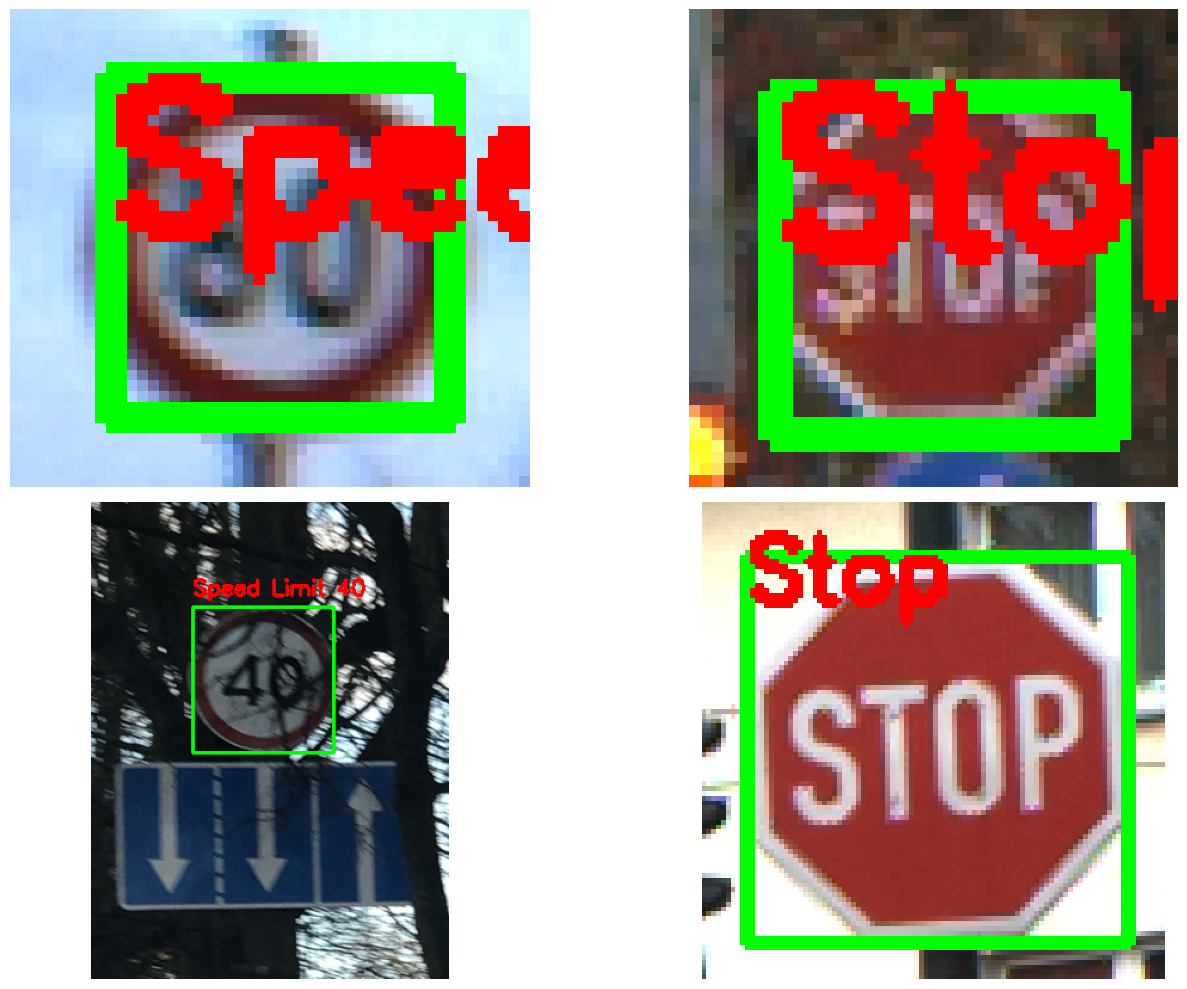

In [5]:
# ==========================================================
# 🟢 PART B - STEP 4 : Visualize Random Images with Bounding Boxes (RUN ONLY ONCE)
# ==========================================================

import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Dataset path
DATASET_PATH = Path("Self-Driving Cars.yolov8")

# Read class names from YAML
import yaml
with open(DATASET_PATH / "data.yaml", "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]

# Training image folder
image_folder = DATASET_PATH / "train/images"
label_folder = DATASET_PATH / "train/labels"

# Select 4 random images
random_images = random.sample(list(image_folder.glob("*")), 4)

plt.figure(figsize=(15,10))

for i, image_path in enumerate(random_images):

    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    label_path = label_folder / (image_path.stem + ".txt")

    if label_path.exists():

        with open(label_path) as f:
            labels = f.readlines()

        for label in labels:

            cls, x, y, bw, bh = map(float, label.split())

            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)

            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

            cv2.putText(
                img,
                class_names[int(cls)],
                (x1, max(y1-10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255,0,0),
                2
            )

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

📊 CLASS DISTRIBUTION
Green Light          : 542
Red Light            : 585
Speed Limit 10       : 19
Speed Limit 100      : 267
Speed Limit 110      : 101
Speed Limit 120      : 252
Speed Limit 20       : 285
Speed Limit 30       : 334
Speed Limit 40       : 235
Speed Limit 50       : 283
Speed Limit 60       : 301
Speed Limit 70       : 318
Speed Limit 80       : 323
Speed Limit 90       : 168
Stop                 : 285


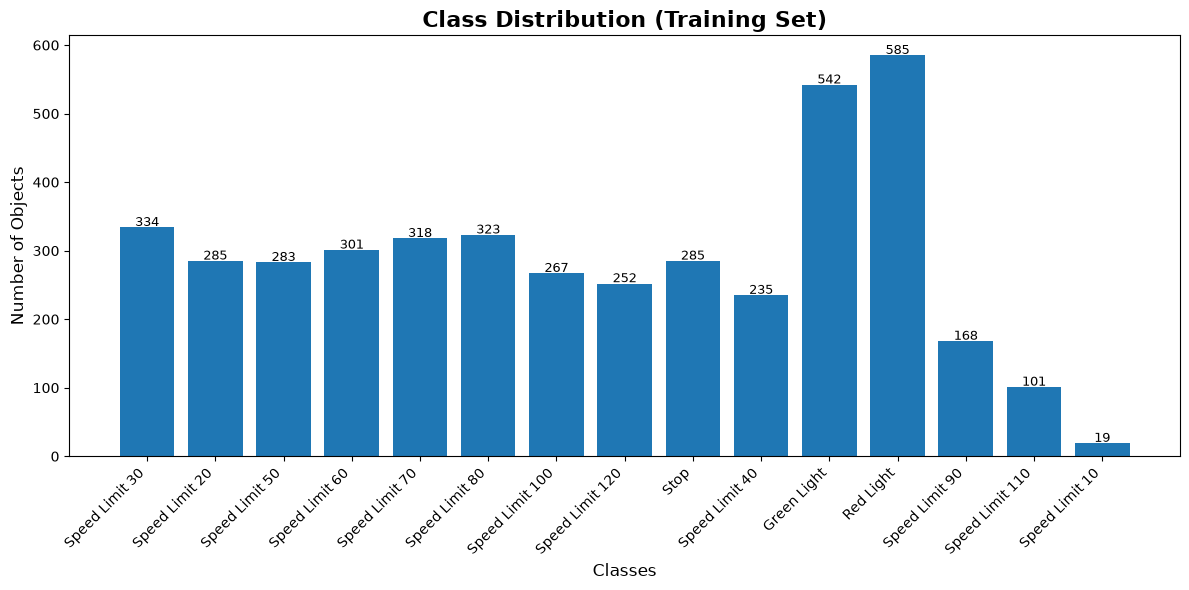

In [6]:
# ==========================================================
# 🟢 PART B - STEP 5 : Class Distribution Analysis (RUN ONLY ONCE)
# ==========================================================

from collections import Counter
import matplotlib.pyplot as plt

# Counter to store object count per class
class_counter = Counter()

# Read all label files from training set
label_files = list((DATASET_PATH / "train/labels").glob("*.txt"))

for label_file in label_files:
    
    with open(label_file, "r") as file:
        labels = file.readlines()
    
    for label in labels:
        class_id = int(label.split()[0])
        class_counter[class_names[class_id]] += 1

# Convert to lists
classes = list(class_counter.keys())
counts = list(class_counter.values())

# Print class distribution
print("=" * 60)
print("📊 CLASS DISTRIBUTION")
print("=" * 60)

for cls, count in sorted(class_counter.items()):
    print(f"{cls:<20} : {count}")

# Plot graph
plt.figure(figsize=(12,6))

bars = plt.bar(classes, counts)

plt.title("Class Distribution (Training Set)", fontsize=16, fontweight='bold')
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Number of Objects", fontsize=12)

plt.xticks(rotation=45, ha="right")

# Display count above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        str(int(height)),
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

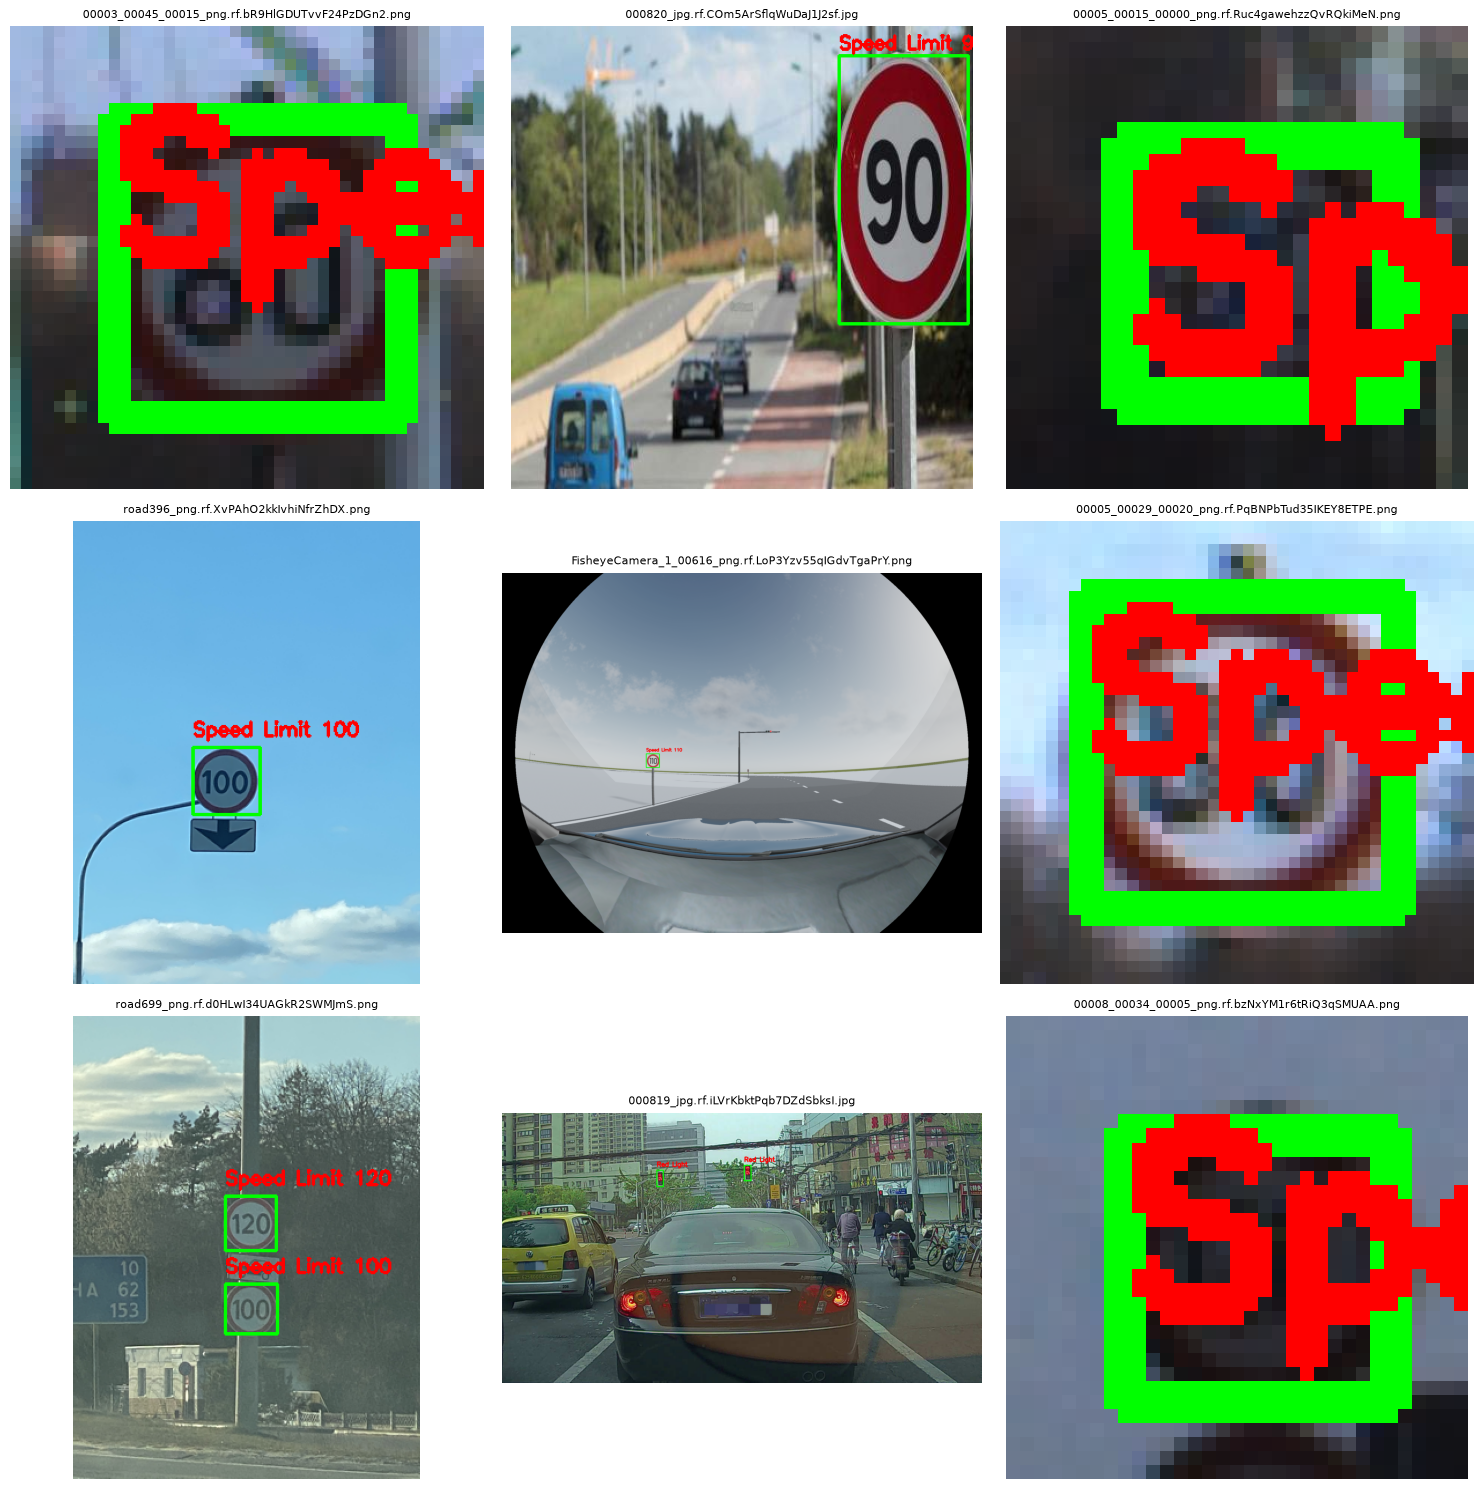

In [7]:
# ==========================================================
# 🟢 PART C - STEP 6 : Display Random Images with Bounding Boxes (RUN ONLY ONCE)
# ==========================================================

import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
image_folder = DATASET_PATH / "train/images"
label_folder = DATASET_PATH / "train/labels"

# Randomly select 9 images
image_paths = random.sample(list(image_folder.glob("*")), 9)

plt.figure(figsize=(15, 15))

for idx, image_path in enumerate(image_paths):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    label_path = label_folder / (image_path.stem + ".txt")

    if label_path.exists():

        with open(label_path, "r") as f:
            labels = f.readlines()

        for label in labels:

            cls, x, y, bw, bh = map(float, label.split())

            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)

            cv2.putText(
                image,
                class_names[int(cls)],
                (x1, max(20, y1-10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                (255,0,0),
                2
            )

    plt.subplot(3,3,idx+1)
    plt.imshow(image)
    plt.title(image_path.name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 🟢 PART C - STEP 7 : Dataset Summary Table (RUN ONLY ONCE)
# ==========================================================

summary = pd.DataFrame({
    "Dataset Split": ["Training", "Validation", "Testing"],
    "Images": [
        len(train_images),
        len(valid_images),
        len(test_images)
    ]
})

summary["Percentage"] = (
    summary["Images"] /
    summary["Images"].sum() * 100
).round(2)

summary

,Dataset Split,Images,Percentage
0,Training,3530,71.04
1,Validation,801,16.12
2,Testing,638,12.84


In [9]:
import ultralytics
print(ultralytics.__version__)

8.4.80


In [10]:
# ==========================================================
# 🟢 PART D - STEP 8 : Train YOLOv8 Model (RUN ONLY ONCE)
# ==========================================================

from ultralytics import YOLO
import torch

print("=" * 70)
print("🚀 TRAFFIC SIGN DETECTION MODEL TRAINING")
print("=" * 70)

# ----------------------------------------------------------
# Check Device
# ----------------------------------------------------------
device = 0 if torch.cuda.is_available() else "cpu"

print(f"Training Device : {'GPU' if device == 0 else 'CPU'}")

# ----------------------------------------------------------
# Load Pretrained YOLOv8 Nano Model
# ----------------------------------------------------------
model = YOLO("yolov8n.pt")

# ----------------------------------------------------------
# Train Model
# ----------------------------------------------------------
results = model.train(

    # Dataset
    data="Self-Driving Cars.yolov8/data.yaml",

    # Training Parameters
    epochs=50,
    patience=10,

    imgsz=640,
    batch=8,

    # Hardware
    device=device,
    workers=2,

    # Optimization
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,

    # Transfer Learning
    pretrained=True,

    # Save Results
    project="runs/detect",
    name="TrafficSignDetection",

    save=True,
    exist_ok=True,
    plots=True,
    verbose=True

)

print("\n" + "=" * 70)
print("✅ MODEL TRAINING COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\n📁 Best Model Location:")
print("runs/detect/TrafficSignDetection/weights/best.pt")

🚀 TRAFFIC SIGN DETECTION MODEL TRAINING
Training Device : GPU
Ultralytics 8.4.80  Python-3.12.10 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=Self-Driving Cars.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Traffic

In [11]:
project="runs"
name="TrafficSignDetection"

In [12]:
# ==========================================================
# 🟢 PART E - STEP 9 : Load Best Model (RUN ONLY ONCE)
# ==========================================================

from ultralytics import YOLO
from pathlib import Path

# Best model path
MODEL_PATH = Path(
    "runs/detect/runs/detect/TrafficSignDetection/weights/best.pt"
)

# Load model
model = YOLO(str(MODEL_PATH))

print("=" * 70)
print("✅ Best Model Loaded Successfully")
print("=" * 70)
print(f"Model Path : {MODEL_PATH.resolve()}")

✅ Best Model Loaded Successfully
Model Path : D:\Major Project\runs\detect\runs\detect\TrafficSignDetection\weights\best.pt


In [13]:
# ==========================================================
# 🟢 PART E - STEP 10 : Evaluate Model (RUN ONLY ONCE)
# ==========================================================

metrics = model.val(
    data="Self-Driving Cars.yolov8/data.yaml",
    split="test",
    imgsz=640,
    batch=8,
    device=0
)

print("\n✅ Model Evaluation Completed Successfully!")

Ultralytics 8.4.80  Python-3.12.10 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 224.8418.7 MB/s, size: 318.9 KB)
val: Scanning D:\Major Project\Self-Driving Cars.yolov8\test\labels... 638 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638 1.4Kit/s 0.5s<0.1s
val: New cache created: D:\Major Project\Self-Driving Cars.yolov8\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 80/80 11.9it/s 6.8s0.1s
                   all        638        770      0.894      0.873      0.921      0.789
           Green Light         77        110      0.888      0.864      0.891       0.55
             Red Light         71         94      0.828      0.702      0.794      0.502
        Speed Limit 10          2          3      0.383      0.333       0.45      0.377
  

In [14]:
# ==========================================================
# 🟢 PART E - STEP 11 : Performance Metrics (RUN ONLY ONCE)
# ==========================================================

print("=" * 70)
print("📊 MODEL PERFORMANCE")
print("=" * 70)

print(f"Precision (P)   : {metrics.box.mp:.4f}")
print(f"Recall (R)      : {metrics.box.mr:.4f}")
print(f"mAP@50          : {metrics.box.map50:.4f}")
print(f"mAP@50-95       : {metrics.box.map:.4f}")

print("=" * 70)

📊 MODEL PERFORMANCE
Precision (P)   : 0.8936
Recall (R)      : 0.8726
mAP@50          : 0.9206
mAP@50-95       : 0.7890


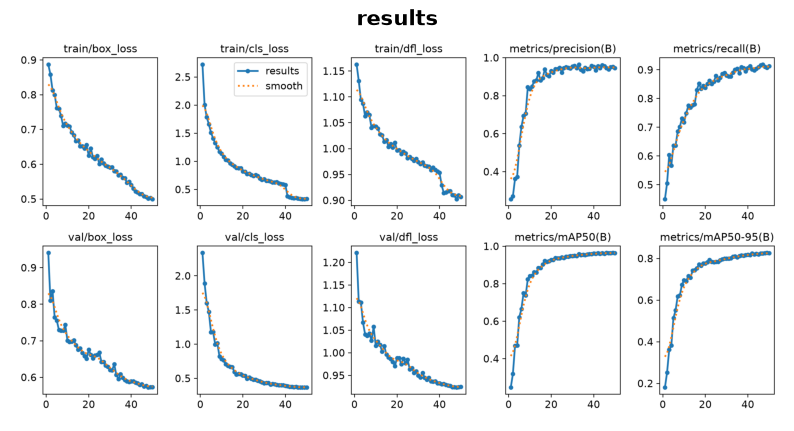

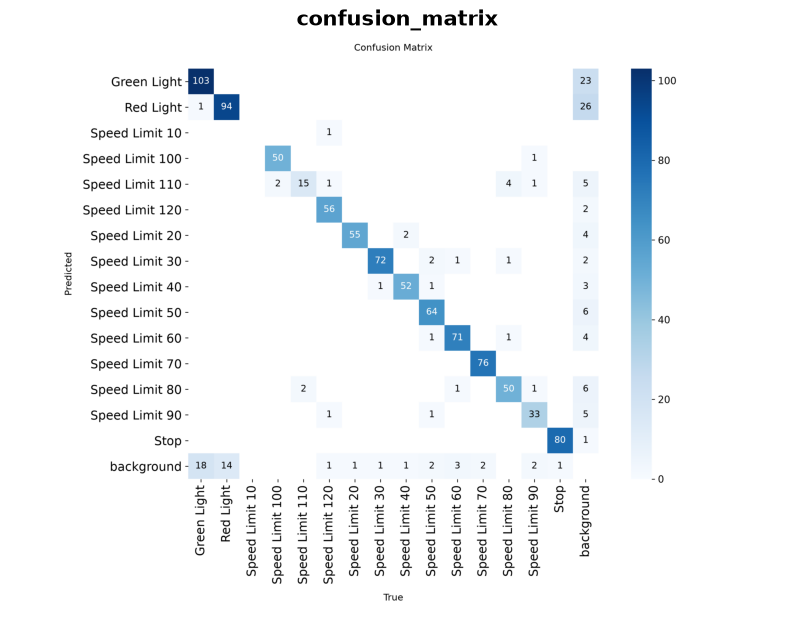

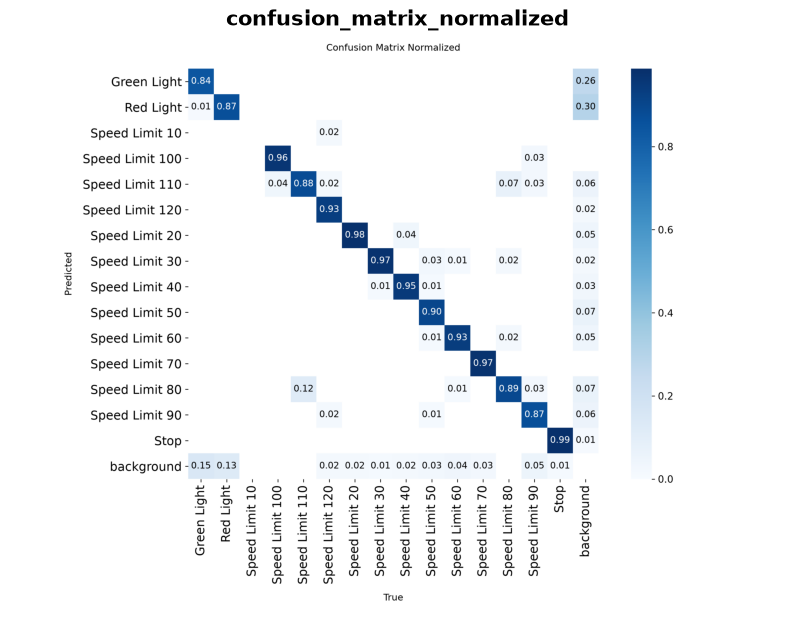

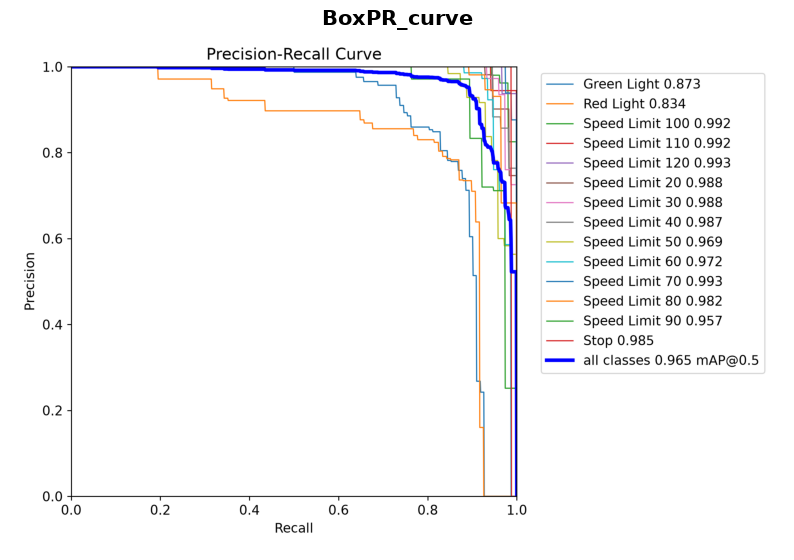

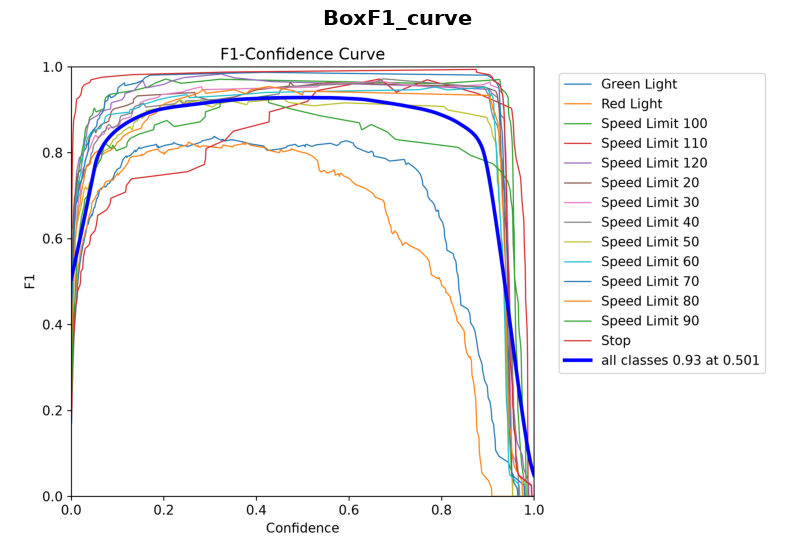

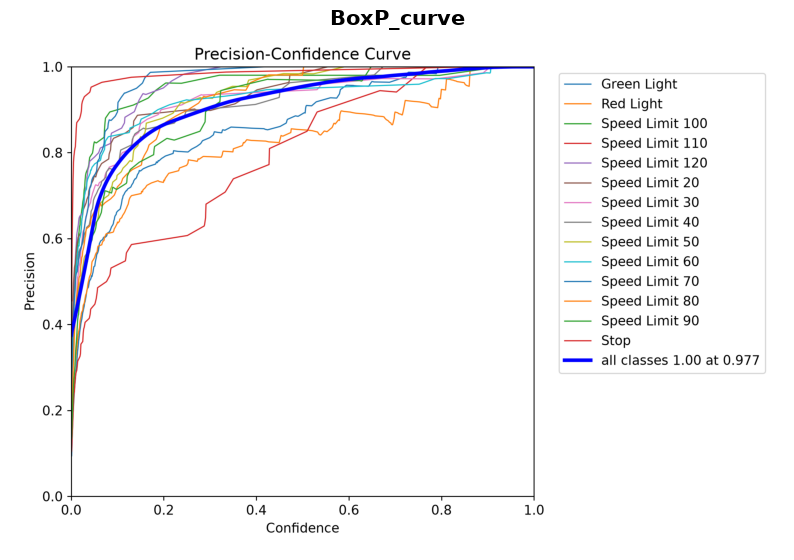

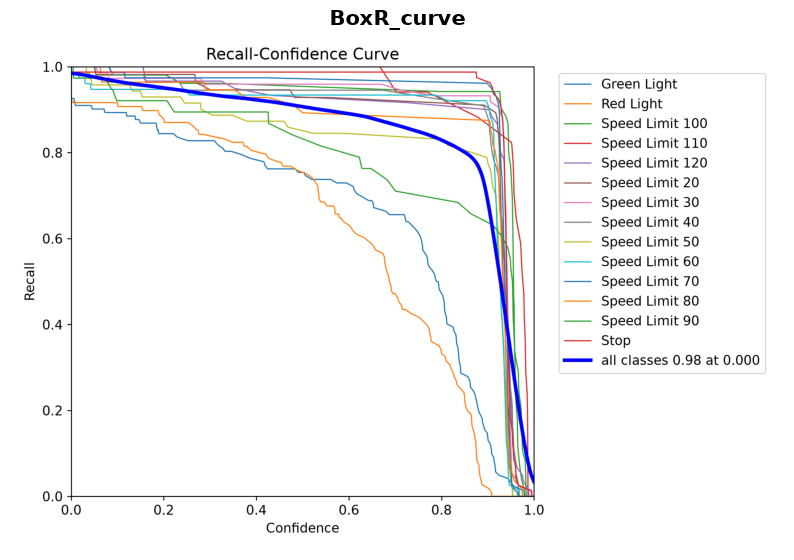

In [15]:
# ==========================================================
# 🟢 PART E - STEP 12 : Display Evaluation Graphs (RUN ONLY ONCE)
# ==========================================================

from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# Folder containing training results
RESULTS_PATH = Path("runs/detect/runs/detect/TrafficSignDetection")

graphs = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png"
]

for graph in graphs:

    img_path = RESULTS_PATH / graph

    if img_path.exists():

        plt.figure(figsize=(10,8))
        plt.imshow(Image.open(img_path))
        plt.title(graph.replace(".png",""), fontsize=15, fontweight="bold")
        plt.axis("off")
        plt.show()

    else:
        print(f"❌ {graph} not found.")

In [16]:
# ==========================================================
# 🟢 PART E - STEP 13 : Performance Comparison Table (RUN ONLY ONCE)
# ==========================================================

import pandas as pd

comparison = pd.DataFrame({

    "Metric":[
        "Precision",
        "Recall",
        "mAP@50",
        "mAP@50-95"
    ],

    "Validation":[
        95.3,
        90.7,
        96.5,
        82.6
    ],

    "Test":[
        round(metrics.box.mp*100,2),
        round(metrics.box.mr*100,2),
        round(metrics.box.map50*100,2),
        round(metrics.box.map*100,2)
    ]

})

comparison

,Metric,Validation,Test
0,Precision,95.3,89.36
1,Recall,90.7,87.26
2,mAP@50,96.5,92.06
3,mAP@50-95,82.6,78.90


In [17]:
# ==========================================================
# 🟢 PART E - STEP 14 : Final Model Summary (RUN ONLY ONCE)
# ==========================================================

print("="*70)
print("🚦 TRAFFIC SIGN DETECTION MODEL SUMMARY")
print("="*70)

print(f"Model                : YOLOv8 Nano")
print(f"Dataset              : Self-Driving Cars")
print(f"Total Images         : 4969")
print(f"Training Images      : 3530")
print(f"Validation Images    : 801")
print(f"Testing Images       : 638")
print(f"Number of Classes    : 15")

print("-"*70)

print(f"Training Device      : NVIDIA RTX 3050 6GB")
print(f"Image Size           : 640 x 640")
print(f"Batch Size           : 8")
print(f"Maximum Epochs       : 50")

print("-"*70)

print(f"Precision            : {metrics.box.mp:.4f}")
print(f"Recall               : {metrics.box.mr:.4f}")
print(f"mAP@50               : {metrics.box.map50:.4f}")
print(f"mAP@50-95            : {metrics.box.map:.4f}")

print("-"*70)

print("Best Model           : best.pt")
print("Training Status      : COMPLETED")
print("Inference Ready      : YES")

print("="*70)

🚦 TRAFFIC SIGN DETECTION MODEL SUMMARY
Model                : YOLOv8 Nano
Dataset              : Self-Driving Cars
Total Images         : 4969
Training Images      : 3530
Validation Images    : 801
Testing Images       : 638
Number of Classes    : 15
----------------------------------------------------------------------
Training Device      : NVIDIA RTX 3050 6GB
Image Size           : 640 x 640
Batch Size           : 8
Maximum Epochs       : 50
----------------------------------------------------------------------
Precision            : 0.8936
Recall               : 0.8726
mAP@50               : 0.9206
mAP@50-95            : 0.7890
----------------------------------------------------------------------
Best Model           : best.pt
Training Status      : COMPLETED
Inference Ready      : YES


In [2]:
from ultralytics import YOLO
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tkinter import Tk, filedialog

prediction_model = YOLO(
    r"D:\Major Project\runs\detect\runs\detect\TrafficSignDetection\weights\best.pt"
)

print("✅ Model Loaded Successfully")

KeyboardInterrupt: 

In [2]:
import torch

print(torch.__file__)
print(torch.__version__)

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\torch\__init__.py
2.12.1+cu126


In [1]:
# ==========================================================
# 🔵 Predict Image (RUN ANYTIME)
# ==========================================================

from tkinter import Tk, filedialog
import cv2
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================================
# Image Filters
# ==========================================================

import numpy as np

# ==========================================================
# Image Filters
# ==========================================================

import numpy as np

def night_vision(img):
    img = img.copy()

    # Convert BGR → HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)

    # Darken image
    hsv[:, :, 2] *= 0.45

    # Reduce saturation
    hsv[:, :, 1] *= 0.70

    hsv[:, :, 2] = np.clip(hsv[:, :, 2], 0, 255)
    hsv[:, :, 1] = np.clip(hsv[:, :, 1], 0, 255)

    # Convert HSV → BGR
    night = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    # Slight green tint
    night[:, :, 1] = cv2.add(night[:, :, 1], 20)

    return night

def fog_filter(img):

    img = img.copy()

    h, w = img.shape[:2]

    # White fog layer
    fog = np.full((h, w, 3), 255, dtype=np.uint8)

    # Dense fog
    foggy = cv2.addWeighted(img, 0.60, fog, 0.40, 0)

    # Strong blur
    foggy = cv2.GaussianBlur(foggy, (15, 15), 0)

    # Lower contrast
    foggy = cv2.convertScaleAbs(
        foggy,
        alpha=0.80,
        beta=20
    )

    return foggy


def rain_filter(img):

    rain = img.copy()

    h, w = rain.shape[:2]

    # Dense rain
    for _ in range(3500):

        x = np.random.randint(0, w)
        y = np.random.randint(0, h)

        length = np.random.randint(18, 35)

        cv2.line(
            rain,
            (x, y),
            (x + 3, y + length),
            (210, 210, 210),
            2
        )

    # Heavy blur
    rain = cv2.GaussianBlur(rain, (9, 9), 1.8)

    # Darker rainy weather
    rain = cv2.convertScaleAbs(
        rain,
        alpha=0.65,
        beta=-15
    )

    return rain

def gaussian_filter(img):

    img = img.copy()

    return cv2.GaussianBlur(img, (21, 21), 0)
# ---------------- Select Image ----------------

root = Tk()
root.withdraw()
root.attributes("-topmost", True)

image_path = filedialog.askopenfilename(
    title="Select Traffic Sign Image",
    filetypes=[("Image Files", "*.jpg *.jpeg *.png *.bmp *.webp")]
)

root.destroy()

if image_path == "":
    print("No image selected.")
    raise SystemExit

print("Selected Image:", image_path)

# ---------------- Prediction ----------------

# ==========================================================
# Test Original + Filtered Images
# ==========================================================

# Read image in BGR (DO NOT convert here)
original = cv2.imread(image_path)

images = {
    "Original": original.copy(),
    "Night Vision": night_vision(original.copy()),
    "Fog": fog_filter(original.copy()),
    "Rain": rain_filter(original.copy()),
    "Gaussian Blur": gaussian_filter(original.copy())
}
for title, img in images.items():

    print("\n" + "="*70)
    print(title.upper())
    print("="*70)

    # ---------------- Prediction ----------------
    results = prediction_model.predict(
        source=img,
        conf=0.25,
        imgsz=640,
        save=False,
        verbose=False
    )

    # Prediction image returned by YOLO
    predicted = results[0].plot()

    # ---------------- Convert ONLY for Display ----------------
    display_original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    display_prediction = cv2.cvtColor(predicted, cv2.COLOR_BGR2RGB)

    # ---------------- Display ----------------
    plt.figure(figsize=(15,6))

    plt.subplot(1,2,1)
    plt.imshow(display_original)
    plt.title(title)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(display_prediction)
    plt.title("Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ---------------- Detection Report ----------------
    report = []

    for i, box in enumerate(results[0].boxes, start=1):

        cls = int(box.cls[0])
        conf = float(box.conf[0])

        report.append({
            "No.": i,
            "Detected Object": prediction_model.names[cls],
            "Confidence (%)": round(conf * 100, 2)
        })

    df = pd.DataFrame(report)

    if len(df):
        display(df)
    else:
        print("No objects detected.")

    print(f"Total Objects Detected : {len(df)}")

KeyboardInterrupt: 